# Mastering Imperfect Information with Deep Recurrent Q-Networks
## Leduc Hold'em — DRQN vs DQN vs Baselines

**This notebook trains and compares 4 agents:**

1. **DRQN** (Deep Recurrent Q-Network with LSTM memory)
2. **DQN** (Standard feedforward DQN - memoryless baseline)
3. **Random Agent** (baseline)
4. **Heuristic Agent** (rule-based baseline)

**Evaluations:**
- DRQN vs Random, Heuristic, DQN
- DQN vs Random, Heuristic
- **Total: 5 matchups**

## 1. Setup & Installation

In [18]:
!pip install -q rlcard

import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dependencies installed")
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

✓ Dependencies installed
✓ Device: cpu
✓ PyTorch version: 2.10.0+cpu


## 2. Clone Repository

In [19]:
import os
import sys

# Clone repository (change YOUR_USERNAME)
!git clone https://github.com/Aghaei-Amirmasoud/DLPW.git
%cd DLPW

sys.path.insert(0, '/content/DLPW')
print("Repository cloned and path configured")

Cloning into 'DLPW'...
remote: Enumerating objects: 140, done.
remote: Counting objects: 100% (140/140), done.
remote: Compressing objects: 100% (98/98), done.
remote: Total 140 (delta 64), reused 116 (delta 40), pack-reused 0 (from 0)
Receiving objects: 100% (140/140), 844.85 KiB | 12.24 MiB/s, done.
Resolving deltas: 100% (64/64), done.
/content/DLPW/DLPW
✓ Repository cloned and path configured


## 3. Configuration

In [20]:
import config

# Adjust for Colab (increase for better results)
config.NUM_EPISODES_PHASE1 = 8000
config.NUM_EPISODES_PHASE2 = 22000
config.EPSILON_RESET_PHASE2 = 0.1
config.MAX_SEQUENCE_LENGTH = None
config.EPSILON_MIN = 0.05

# Paths
config.OUTPUT_DIR = '/content/DLPW/outputs'
config.MODEL_DIR = '/content/DLPW/outputs/models'
config.PLOT_DIR = '/content/DLPW/outputs/plots'

os.makedirs(config.OUTPUT_DIR, exist_ok=True)
os.makedirs(config.MODEL_DIR, exist_ok=True)
os.makedirs(config.PLOT_DIR, exist_ok=True)

print("Configuration set")
print(f"Episodes per phase 1: {config.NUM_EPISODES_PHASE1}")
print(f"Episodes per phase 2: {config.NUM_EPISODES_PHASE2}")
print(f"Epsilon reset: {config.EPSILON_RESET_PHASE2}")

✓ Configuration set
  Episodes per phase 1: 8000
  Episodes per phase 2: 22000
  Epsilon reset: 0.1


## 4. Import Modules

In [21]:
import rlcard
from rlcard.utils import set_seed
from rlcard.agents import RandomAgent, DQNAgent
import matplotlib.pyplot as plt
import numpy as np
import logging

from config import *
from agents import DRQNAgent, ConservativeHeuristicAgent
from training import CurriculumTrainer
from evaluation import (
    evaluate_agents,
    compute_action_distribution,
    print_evaluation_summary,
    print_advanced_analysis,
    compare_agents,
    statistical_significance,
    analyze_queen_play,
    analyze_round_performance,
    compare_queen_play
)
from analysis import plot_training_curves, plot_comparison_curves, plot_ev_comparison_bar

# Suppress RLCard INFO logs
logging.getLogger('rlcard').setLevel(logging.WARNING)

print("All modules imported")

✓ All modules imported


## 5. Environment Setup

In [22]:
set_seed(SEED)
env = rlcard.make(ENV_NAME)

raw_shape = env.state_shape[0]
state_shape = raw_shape[0] if isinstance(raw_shape, list) else raw_shape
num_actions = env.num_actions

print(f'Environment: {ENV_NAME}')
print(f'State shape: {state_shape}, Actions: {num_actions}')

✓ Environment: leduc-holdem
✓ State shape: 36, Actions: 4


## 6. Initialize Agents

In [23]:
# DRQN Agent (with LSTM memory)
agent_drqn = DRQNAgent(
    state_shape=state_shape,
    num_actions=num_actions,
    device=DEVICE,
    hidden_size=HIDDEN_SIZE,
    lr=LEARNING_RATE,
    gamma=GAMMA,
    epsilon_start=EPSILON_START,
    epsilon_min=EPSILON_MIN,
    epsilon_decay=EPSILON_DECAY,
    buffer_capacity=BUFFER_CAPACITY,
    batch_size=BATCH_SIZE,
    min_replay=MIN_REPLAY_SIZE,
    target_update_freq=TARGET_UPDATE_FREQ,
    max_sequence_length=MAX_SEQUENCE_LENGTH
)

# DQN Agent (feedforward baseline)
agent_dqn = DQNAgent(
    num_actions=num_actions,
    state_shape=env.state_shape[0],
    mlp_layers=[HIDDEN_SIZE, HIDDEN_SIZE],
    device=DEVICE
)

# Baseline agents
agent_random = RandomAgent(num_actions)
agent_heuristic = ConservativeHeuristicAgent(num_actions)

print("All agents initialized")
if MAX_SEQUENCE_LENGTH is not None:
    print(f"DRQN using max sequence length: {MAX_SEQUENCE_LENGTH}")

✓ All agents initialized


## 7. Train DRQN (Two-Phase Curriculum)

**Phase 1**: Learn basic card strength against Random agent  
**Phase 2**: Learn exploitation against Heuristic agent

In [24]:
trainer_drqn = CurriculumTrainer(
    env=env,
    agent=agent_drqn,
    opponent_phase1=agent_random,
    opponent_phase2=agent_heuristic
)

drqn_history = trainer_drqn.train()

# Save model
agent_drqn.save_model(DRQN_CHECKPOINT)
print(f"\nDRQN training complete. Model saved to {DRQN_CHECKPOINT}")

PHASE 1: Training vs Random Agent (0-8000)
[P1] Ep 00000 | ε=1.000 | EV vs Random: +1.254 | EV vs Heuristic: -1.022
[P1] Ep 01000 | ε=0.704 | EV vs Random: +1.211 | EV vs Heuristic: -0.574
[P1] Ep 02000 | ε=0.427 | EV vs Random: +1.190 | EV vs Heuristic: -0.687
[P1] Ep 03000 | ε=0.259 | EV vs Random: +1.159 | EV vs Heuristic: -0.961
[P1] Ep 04000 | ε=0.157 | EV vs Random: +1.105 | EV vs Heuristic: -0.826
[P1] Ep 05000 | ε=0.095 | EV vs Random: +1.117 | EV vs Heuristic: -0.722
[P1] Ep 06000 | ε=0.058 | EV vs Random: +1.102 | EV vs Heuristic: -1.115
[P1] Ep 07000 | ε=0.050 | EV vs Random: +1.018 | EV vs Heuristic: -0.963

PHASE 2: Fine-tuning vs Heuristic (8000-30000)
[Phase 2] Epsilon reset: 0.050 → 0.100
[Phase 2] Rationale: Encourage exploration of new strategies vs Heuristic

[P2] Ep 08000 | ε=0.100 | EV vs Random: +1.032 | EV vs Heuristic: -0.971
[P2] Ep 09000 | ε=0.061 | EV vs Random: +0.838 | EV vs Heuristic: -0.258
[P2] Ep 10000 | ε=0.050 | EV vs Random: +0.929 | EV vs Heuristic:

RuntimeError: Parent directory outputs/models does not exist.

## 8. Train DQN (Baseline Comparison)

In [25]:
trainer_dqn = CurriculumTrainer(
    env=env,
    agent=agent_dqn,
    opponent_phase1=agent_random,
    opponent_phase2=agent_heuristic
)

dqn_history = trainer_dqn.train()
print("\nDQN training complete")

PHASE 1: Training vs Random Agent (0-8000)
[P1] Ep 00000 | ε=0.000 | EV vs Random: +0.446 | EV vs Heuristic: -0.886
INFO - Step 32, rl-loss: 2.5114152431488037
INFO - Copied model parameters to target network.
INFO - Step 645, rl-loss: 0.4804840087890625
INFO - Copied model parameters to target network.
INFO - Step 1228, rl-loss: 3.1700527667999268
INFO - Copied model parameters to target network.
INFO - Step 1358, rl-loss: 2.0545012950897217[P1] Ep 01000 | ε=0.000 | EV vs Random: +0.824 | EV vs Heuristic: -1.258
INFO - Step 1803, rl-loss: 0.4313294291496277
INFO - Copied model parameters to target network.
INFO - Step 2367, rl-loss: 0.9954249858856201
INFO - Copied model parameters to target network.
INFO - Step 2724, rl-loss: 1.6259030103683472[P1] Ep 02000 | ε=0.000 | EV vs Random: +1.065 | EV vs Heuristic: -1.223
INFO - Step 2955, rl-loss: 2.561671257019043
INFO - Copied model parameters to target network.
INFO - Step 3528, rl-loss: 1.4862178564071655
INFO - Copied model parameters

## 9. Training Curves Visualization

Saved training curves to /content/DLPW/outputs/plots/drqn_training_curves.png


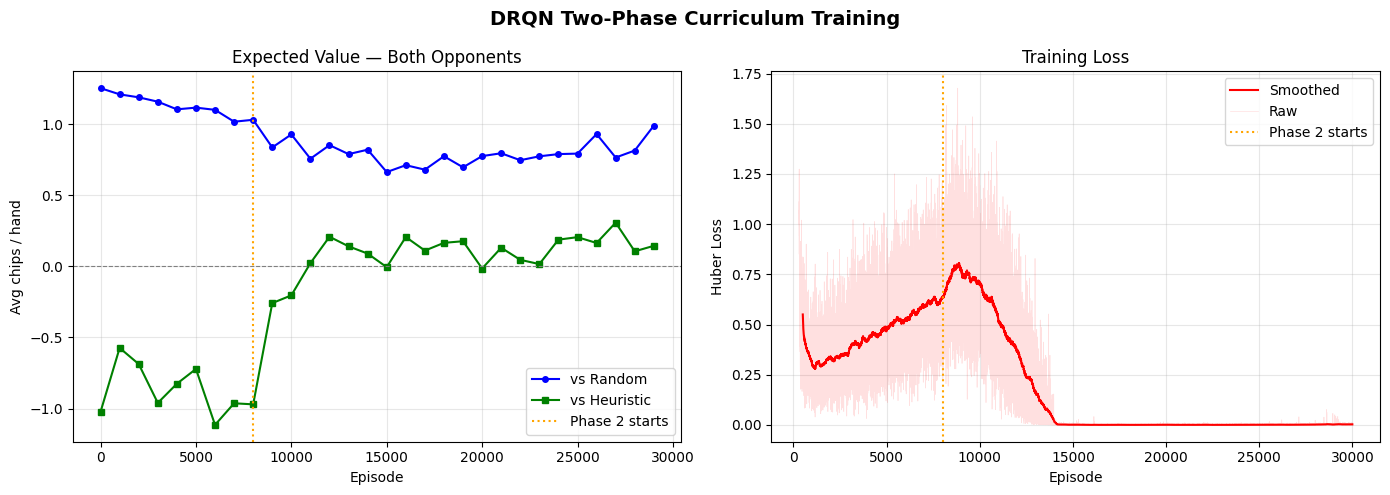

In [26]:
# DRQN training curves
plot_training_curves(
    ev_history_random=drqn_history['ev_random'],
    ev_history_heuristic=drqn_history['ev_heuristic'],
    loss_history=drqn_history['loss'],
    phase1_episodes=NUM_EPISODES_PHASE1,
    save_path=f'{PLOT_DIR}/drqn_training_curves.png'
)

Saved comparison curves to /content/DLPW/outputs/plots/drqn_vs_dqn_comparison.png


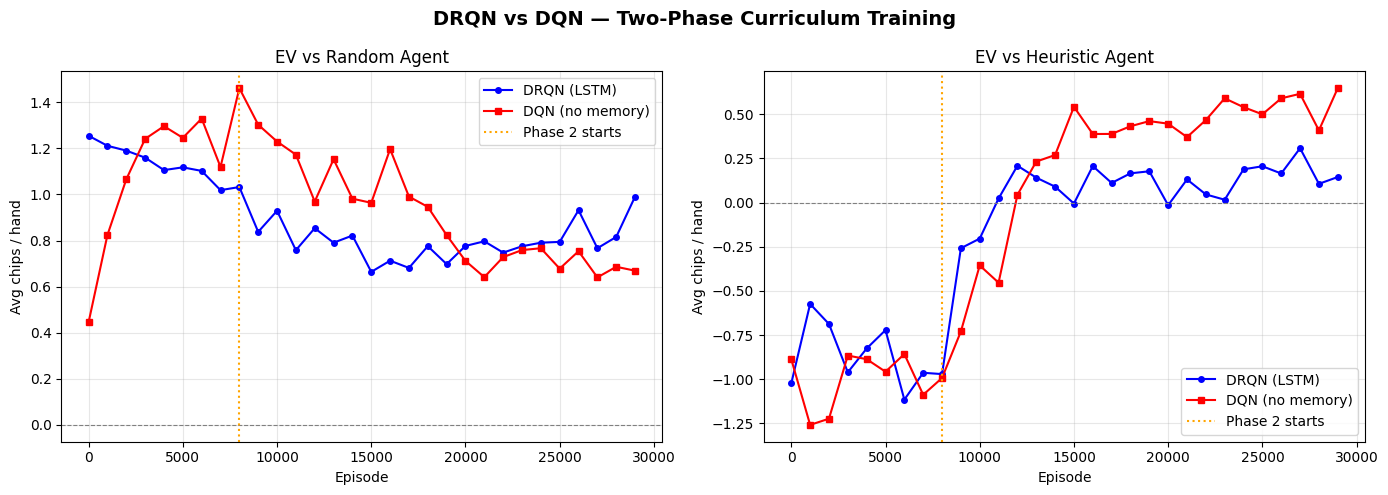

In [27]:
# DRQN vs DQN comparison
plot_comparison_curves(
    drqn_hist_random=drqn_history['ev_random'],
    drqn_hist_heuristic=drqn_history['ev_heuristic'],
    dqn_hist_random=dqn_history['ev_random'],
    dqn_hist_heuristic=dqn_history['ev_heuristic'],
    phase1_episodes=NUM_EPISODES_PHASE1,
    save_path=f'{PLOT_DIR}/drqn_vs_dqn_comparison.png'
)

## 10. Final Evaluation

In [28]:
print(f"\n{'='*60}")
print(f"FINAL EVALUATION ({NUM_EVAL_HANDS} hands per matchup)")
print(f"{'='*60}")

results = {}

# DRQN evaluations
print('\nDRQN vs ...')
ev_vs_random, traj_drqn_vs_random = evaluate_agents(
    env, agent_drqn, agent_random, NUM_EVAL_HANDS, 'Random'
)
ev_vs_heuristic, traj_drqn_vs_heuristic = evaluate_agents(
    env, agent_drqn, agent_heuristic, NUM_EVAL_HANDS, 'Heuristic'
)
ev_vs_dqn, traj_drqn_vs_dqn = evaluate_agents(
    env, agent_drqn, agent_dqn, NUM_EVAL_HANDS, 'Standard DQN'
)

# DQN evaluations
print('\nDQN vs ...')
dqn_vs_random, traj_dqn_vs_random = evaluate_agents(
    env, agent_dqn, agent_random, NUM_EVAL_HANDS, 'Random'
)
dqn_vs_heuristic, traj_dqn_vs_heuristic = evaluate_agents(
    env, agent_dqn, agent_heuristic, NUM_EVAL_HANDS, 'Heuristic'
)

# Store results
results['DRQN vs Random'] = {
    'ev': ev_vs_random,
    'trajectories': traj_drqn_vs_random,
    'action_stats': compute_action_distribution(traj_drqn_vs_random, ACTION_NAMES)
}
results['DRQN vs Heuristic'] = {
    'ev': ev_vs_heuristic,
    'trajectories': traj_drqn_vs_heuristic,
    'action_stats': compute_action_distribution(traj_drqn_vs_heuristic, ACTION_NAMES)
}
results['DRQN vs DQN'] = {
    'ev': ev_vs_dqn,
    'trajectories': traj_drqn_vs_dqn,
    'action_stats': compute_action_distribution(traj_drqn_vs_dqn, ACTION_NAMES)
}
results['DQN vs Random'] = {
    'ev': dqn_vs_random,
    'trajectories': traj_dqn_vs_random,
    'action_stats': compute_action_distribution(traj_dqn_vs_random, ACTION_NAMES)
}
results['DQN vs Heuristic'] = {
    'ev': dqn_vs_heuristic,
    'trajectories': traj_dqn_vs_heuristic,
    'action_stats': compute_action_distribution(traj_dqn_vs_heuristic, ACTION_NAMES)
}


FINAL EVALUATION (5000 hands per matchup)

DRQN vs ...
  Random                        : +0.847 chips/hand
  Heuristic                     : +0.315 chips/hand
  Standard DQN                  : +0.124 chips/hand

DQN vs ...
  Random                        : +0.672 chips/hand
  Heuristic                     : +0.565 chips/hand


## 11. Evaluation Summary & Analysis

In [29]:
# Detailed summary with action distributions and bluff rates
print_evaluation_summary(results)


FINAL EVALUATION SUMMARY

DRQN vs Random
----------------------------------------
  Expected Value: +0.847 chips/hand
  Action Distribution:
    Raise   :  5938 (48.6%)
    Call    :  2629 (21.5%)
    Fold    :  1985 (16.2%)
    Check   :  1664 (13.6%)
  Bluff Rate (raise with Jack): 41.1%  (1680/4087 decisions)

DRQN vs Heuristic
----------------------------------------
  Expected Value: +0.315 chips/hand
  Action Distribution:
    Raise   :  6524 (48.9%)
    Fold    :  5055 (37.9%)
    Call    :   993 (7.4%)
    Check   :   777 (5.8%)
  Bluff Rate (raise with Jack): 28.4%  (1470/5173 decisions)

DRQN vs DQN
----------------------------------------
  Expected Value: +0.124 chips/hand
  Action Distribution:
    Fold    :  6753 (40.1%)
    Raise   :  5106 (30.3%)
    Check   :  2773 (16.5%)
    Call    :  2200 (13.1%)
  Bluff Rate (raise with Jack): 18.9%  (1055/5576 decisions)

DQN vs Random
----------------------------------------
  Expected Value: +0.672 chips/hand
  Action Distribu

## 12. Advanced Analysis

Detailed poker metrics including VPIP, aggression factor, and win rate by hand strength.

In [30]:
# Advanced analysis for all matchups
print_advanced_analysis(results)


ADVANCED ANALYSIS

DRQN vs Random
----------------------------------------
  Playing Style Metrics:
    VPIP (Voluntary Put in Pot):  64.1%
    PFR (Pre-Flop Raise):          45.3%
    Aggression Factor:             2.26
    Went to Showdown:              73.2%
    Fold Percentage:               10.4%
  Round-Specific Aggression:
    Round 1 (Pre-Flop):            55.8% raises
    Round 2 (Post-Flop):           39.9% raises
  Performance by Starting Hand:
    K: 1429/1678 wins (85.2%) | Avg Payoff: +1.43
    Q: 1229/1675 wins (73.4%) | Avg Payoff: +0.58
    J: 1221/1647 wins (74.1%) | Avg Payoff: +0.53

DRQN vs Heuristic
----------------------------------------
  Playing Style Metrics:
    VPIP (Voluntary Put in Pot):  50.9%
    PFR (Pre-Flop Raise):          46.3%
    Aggression Factor:             6.57
    Went to Showdown:              56.1%
    Fold Percentage:               26.6%
  Round-Specific Aggression:
    Round 1 (Pre-Flop):            56.0% raises
    Round 2 (Post-Flop):

## 13. Head-to-Head Comparison: DRQN vs DQN

Direct comparison with playing style metrics.

In [31]:
# Detailed DRQN vs DQN comparison
compare_agents(results, 'DRQN', 'DQN')


HEAD-TO-HEAD COMPARISON: DRQN vs DQN

Direct Matchup:
  DRQN EV: +0.124 chips/hand
  Result: DRQN WINS decisively

Performance vs Baselines:

  vs Random:
    DRQN: +0.847
    DQN: +0.672
    Difference: +0.175 (DRQN better)

  vs Heuristic:
    DRQN: +0.315
    DQN: +0.565
    Difference: -0.251 (DQN better)

Playing Style Comparison:

  Metric                               DRQN              DQN
  -------------------------------------------------------
  VPIP                                64.1%            63.8%
  Pre-Flop Raise                      45.3%            43.8%
  Aggression Factor                   2.26             1.71
  Went to Showdown                    73.2%            66.0%
  Round 1 Aggression                  55.8%            55.5%
  Round 2 Aggression                  39.9%            34.2%


## 14. Statistical Significance Analysis

Verify the DRQN advantage is statistically robust.

In [32]:
# Statistical significance test
sig_test = statistical_significance(results['DRQN vs DQN']['ev'], NUM_EVAL_HANDS)

print("\n" + "="*60)
print("STATISTICAL SIGNIFICANCE TEST: DRQN vs DQN")
print("="*60)
print(f"\nExpected Value: {sig_test['ev']:+.3f} chips/hand")
print(f"Standard Error: ±{sig_test['std_error']:.3f}")
print(f"95% Confidence Interval: [{sig_test['ci_95_lower']:+.3f}, {sig_test['ci_95_upper']:+.3f}]")
print(f"Z-score: {sig_test['z_score']:.2f}")
print(f"P-value: {sig_test['p_value']:.6f}")
print(f"\nStatistically Significant (α=0.05): {'YES ✓' if sig_test['significant'] else 'NO'}")

if sig_test['significant']:
    print("\n" + "="*60)
    print("CONCLUSION: DRQN's memory advantage is STATISTICALLY ROBUST")
    print("="*60)
    print("The LSTM memory provides a significant competitive advantage")
    print("that cannot be attributed to random chance.")


STATISTICAL SIGNIFICANCE TEST: DRQN vs DQN

Expected Value: +0.124 chips/hand
Standard Error: ±0.028
95% Confidence Interval: [+0.069, +0.180]
Z-score: 4.40
P-value: 0.000011

Statistically Significant (α=0.05): YES ✓

CONCLUSION: DRQN's memory advantage is STATISTICALLY ROBUST
The LSTM memory provides a significant competitive advantage
that cannot be attributed to random chance.


## 15. Queen Play Investigation

Detailed analysis of the Queen misplay problem.

In [33]:
# Compare how DRQN and DQN play Queens
compare_queen_play(results, 'DRQN', 'DQN')


QUEEN PLAY COMPARISON: DRQN vs DQN

DRQN Queens vs Heuristic:
  Total Queen Hands: 1682
  Win Rate: 70.2%
  Average Payoff: +0.603
  Fold Rate: 29.8%
  Showdown Rate: 70.2%

  Round 1 Actions:
    Raise:  61.8%
    Call:   0.0%
    Check:  0.0%
    Fold:   38.2%

  Round 2 Actions:
    Raise:  50.7%
    Call:   0.0%
    Check:  0.0%
    Fold:   49.3%

DQN Queens vs Heuristic:
  Total Queen Hands: 1700
  Win Rate: 70.0%
  Average Payoff: +0.565
  Fold Rate: 30.0%
  Showdown Rate: 70.0%

  Round 1 Actions:
    Raise:  62.0%
    Call:   0.0%
    Check:  0.0%
    Fold:   38.0%

  Round 2 Actions:
    Raise:  49.6%
    Call:   0.0%
    Check:  0.0%
    Fold:   50.4%

KEY DIFFERENCES:

Win Rate Gap: +0.2 percentage points (DRQN)
Round 1 Raise Rate: -0.2% (DRQN)
Round 2 Raise Rate: +1.1% (DRQN)


## 16. Round Performance Analysis

In [34]:
# Analyze round-specific performance
print("\n" + "="*60)
print("ROUND-BY-ROUND ANALYSIS")
print("="*60)

for agent_name in ['DRQN', 'DQN']:
    key = f'{agent_name} vs Heuristic'
    if key in results and 'trajectories' in results[key]:
        stats = analyze_round_performance(results[key]['trajectories'])

        print(f'\n{agent_name} vs Heuristic:')
        print(f"  Round 1 Folds: {stats.get('fold_round1_pct', 0):.1f}%")
        print(f"  Round 2 Folds: {stats.get('fold_round2_pct', 0):.1f}%")
        print(f"  Showdown Rate: {stats.get('showdown_pct', 0):.1f}%")

        if 'round1_aggressive_win_rate' in stats:
            print(f"  Round 1 Raise Success: {stats['round1_aggressive_win_rate']:.1f}%")
        if 'round2_aggressive_win_rate' in stats:
            print(f"  Round 2 Raise Success: {stats['round2_aggressive_win_rate']:.1f}%")


ROUND-BY-ROUND ANALYSIS

DRQN vs Heuristic:
  Round 1 Folds: 26.6%
  Round 2 Folds: 0.0%
  Showdown Rate: 73.4%
  Round 1 Raise Success: 92.8%
  Round 2 Raise Success: 90.0%

DQN vs Heuristic:
  Round 1 Folds: 26.5%
  Round 2 Folds: 0.0%
  Showdown Rate: 73.5%
  Round 1 Raise Success: 96.5%
  Round 2 Raise Success: 94.7%
